In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import koreanize_matplotlib

In [3]:
#데이터 불러오기
data = pd.read_table('data/mini.csv',sep=',')

## 1. 데이터 구조 확인

In [5]:
#데이터 정보확인
data.head()

,user_id,subscription_duration,recent_login_time,average_login_time,average_time_per_learning_session,monthly_active_learning_days,total_completed_courses,recent_learning_achievement,abandoned_learning_sessions,community_engagement_level,preferred_difficulty_level,subscription_type,customer_inquiry_history,payment_pattern,target
0,b919c29d,13,14,14.946163,8.427187,18,16,68.360455,3,4,Low,Basic,4,5,0
1,a0a60abb,16,18,18.453224,72.646087,16,13,97.567322,2,3,Medium,Basic,1,6,1
2,b9f171ae,22,1,16.195228,21.774492,13,14,94.358763,3,4,Medium,Premium,0,7,1
3,5dc0ba8b,1,19,17.628656,42.659066,19,18,70.153228,0,3,Low,Basic,1,0,1
4,65c83654,4,5,21.390656,30.744287,19,10,81.917908,2,4,Medium,Basic,3,0,1


In [7]:
data.describe()

,subscription_duration,recent_login_time,average_login_time,average_time_per_learning_session,monthly_active_learning_days,total_completed_courses,recent_learning_achievement,abandoned_learning_sessions,community_engagement_level,customer_inquiry_history,payment_pattern,target
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,11.897400,15.013200,14.994076,54.917720,12.545400,12.227500,75.029513,3.043600,3.886100,2.010500,3.502900,0.619900
std,6.600896,8.362573,3.001869,56.024310,6.932239,3.634125,9.968529,1.755052,1.262175,1.420983,2.311261,0.485435
min,1.000000,1.000000,2.366189,0.011515,1.000000,1.000000,35.941755,0.000000,1.000000,0.000000,0.000000,0.000000
25%,6.000000,8.000000,13.025597,15.276611,7.000000,10.000000,68.278054,2.000000,3.000000,1.000000,1.000000,0.000000
50%,12.000000,15.000000,14.979228,37.578818,13.000000,12.000000,75.126061,3.000000,4.000000,2.000000,4.000000,1.000000
75%,18.000000,22.000000,16.995340,75.584200,19.000000,15.000000,81.718976,4.000000,5.000000,3.000000,6.000000,1.000000
max,23.000000,29.000000,26.998490,503.372616,24.000000,27.000000,112.643828,12.000000,5.000000,10.000000,7.000000,1.000000


In [9]:
data_info = data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   user_id                            10000 non-null  object 
 1   subscription_duration              10000 non-null  int64  
 2   recent_login_time                  10000 non-null  int64  
 3   average_login_time                 10000 non-null  float64
 4   average_time_per_learning_session  10000 non-null  float64
 5   monthly_active_learning_days       10000 non-null  int64  
 6   total_completed_courses            10000 non-null  int64  
 7   recent_learning_achievement        10000 non-null  float64
 8   abandoned_learning_sessions        10000 non-null  int64  
 9   community_engagement_level         10000 non-null  int64  
 10  preferred_difficulty_level         10000 non-null  object 
 11  subscription_type                  10000 non-null  obje

### 1-1. 데이터 구분하기

In [11]:
# 데이터셋의 숫자형 변수와 범주형 변수를 구분
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_columns = data.select_dtypes(include=['object']).columns.tolist()

numeric_columns, categorical_columns

(['subscription_duration',
  'recent_login_time',
  'average_login_time',
  'average_time_per_learning_session',
  'monthly_active_learning_days',
  'total_completed_courses',
  'recent_learning_achievement',
  'abandoned_learning_sessions',
  'community_engagement_level',
  'customer_inquiry_history',
  'payment_pattern',
  'target'],
 ['user_id', 'preferred_difficulty_level', 'subscription_type'])

### 1-2. 결측치 확인

In [13]:
missing_values = data.isnull().sum()
print(missing_values)

user_id                              0
subscription_duration                0
recent_login_time                    0
average_login_time                   0
average_time_per_learning_session    0
monthly_active_learning_days         0
total_completed_courses              0
recent_learning_achievement          0
abandoned_learning_sessions          0
community_engagement_level           0
preferred_difficulty_level           0
subscription_type                    0
customer_inquiry_history             0
payment_pattern                      0
target                               0
dtype: int64


### 1-3. 데이터 가공하기

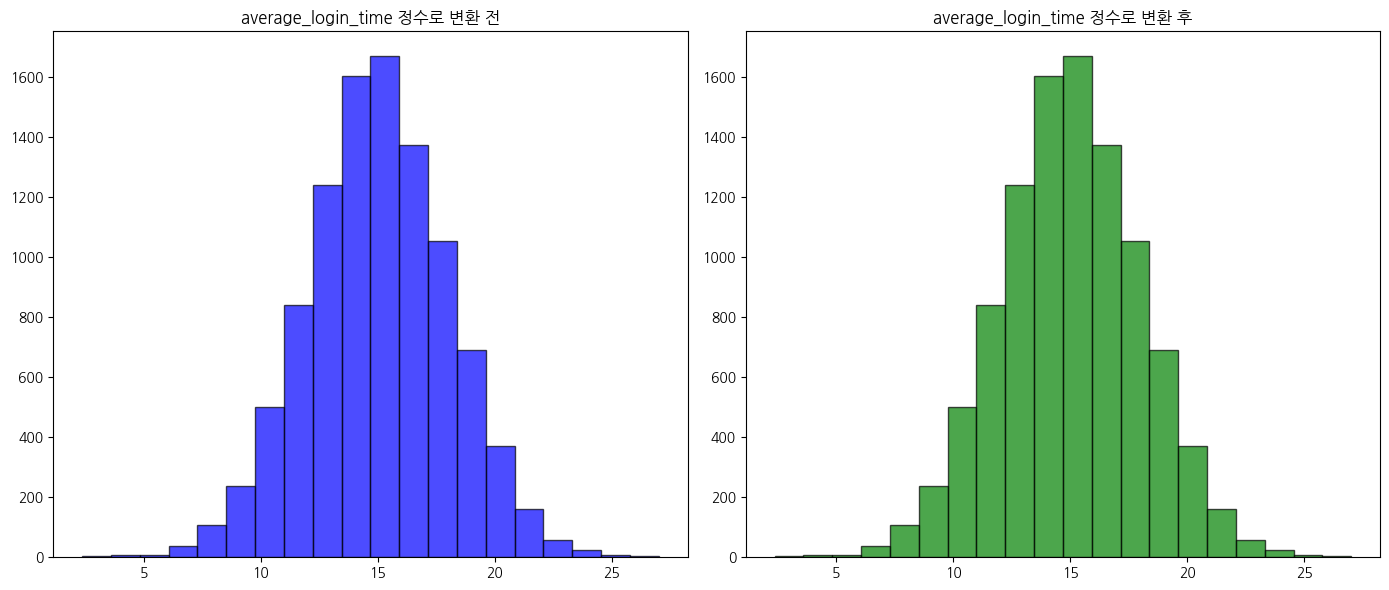

In [15]:
# 원래 데이터와 정수형 데이터의 히스토그램 그리기
plt.figure(figsize=(14, 6))

# 원래 데이터 히스토그램
plt.subplot(1, 2, 1)
plt.hist(data['average_login_time'],bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('average_login_time 정수로 변환 전')


# 정수형 데이터 히스토그램
data['average_login_time_int'] = data['average_login_time'].round().astype(int)
plt.subplot(1, 2, 2)
plt.hist(data['average_login_time'], bins=20, alpha=0.7, color='green', edgecolor='black')
plt.title('average_login_time 정수로 변환 후')

plt.tight_layout()
plt.show()

In [17]:
data['average_login_time_int'] = data['average_login_time'].round().astype(int)
# 기술 통계 계산
original_stats = data['average_login_time'].describe()
integer_stats = data['average_login_time'].describe()

# 결과를 데이터프레임으로 정리
stats_comparison = pd.DataFrame({
    'Original': original_stats,
    'Integer': integer_stats
})

# 결과 출력
print(stats_comparison)

           Original       Integer
count  10000.000000  10000.000000
mean      14.994076     14.994076
std        3.001869      3.001869
min        2.366189      2.366189
25%       13.025597     13.025597
50%       14.979228     14.979228
75%       16.995340     16.995340
max       26.998490     26.998490


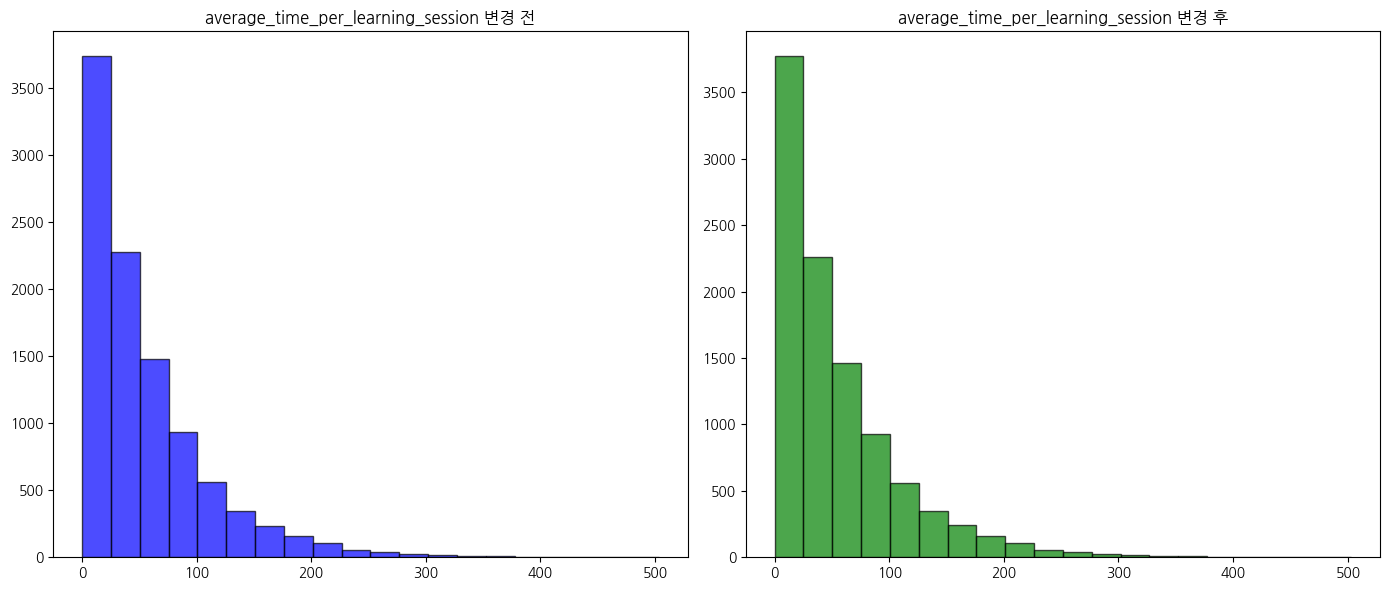

In [19]:
# 원래 데이터와 정수형 데이터의 히스토그램 그리기
plt.figure(figsize=(14, 6))

# 원래 데이터 히스토그램
plt.subplot(1, 2, 1)
plt.hist(data['average_time_per_learning_session'], bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('average_time_per_learning_session 변경 전')

# 정수형 데이터 히스토그램
data['average_time_per_learning_session_int'] = data['average_time_per_learning_session'].round().astype(int)
plt.subplot(1, 2, 2)
plt.hist(data['average_time_per_learning_session_int'], bins=20, alpha=0.7, color='green', edgecolor='black')
plt.title('average_time_per_learning_session 변경 후')

plt.tight_layout()
plt.show()

In [21]:
# 기술 통계 계산
original_stats = data['average_time_per_learning_session'].describe()
integer_stats = data['average_time_per_learning_session_int'].describe()

# 결과를 데이터프레임으로 정리
stats_comparison = pd.DataFrame({
    'Original': original_stats,
    'Integer': integer_stats
})

# 결과 출력
print(stats_comparison)

           Original       Integer
count  10000.000000  10000.000000
mean      54.917720     54.911800
std       56.024310     56.023837
min        0.011515      0.000000
25%       15.276611     15.000000
50%       37.578818     38.000000
75%       75.584200     76.000000
max      503.372616    503.000000


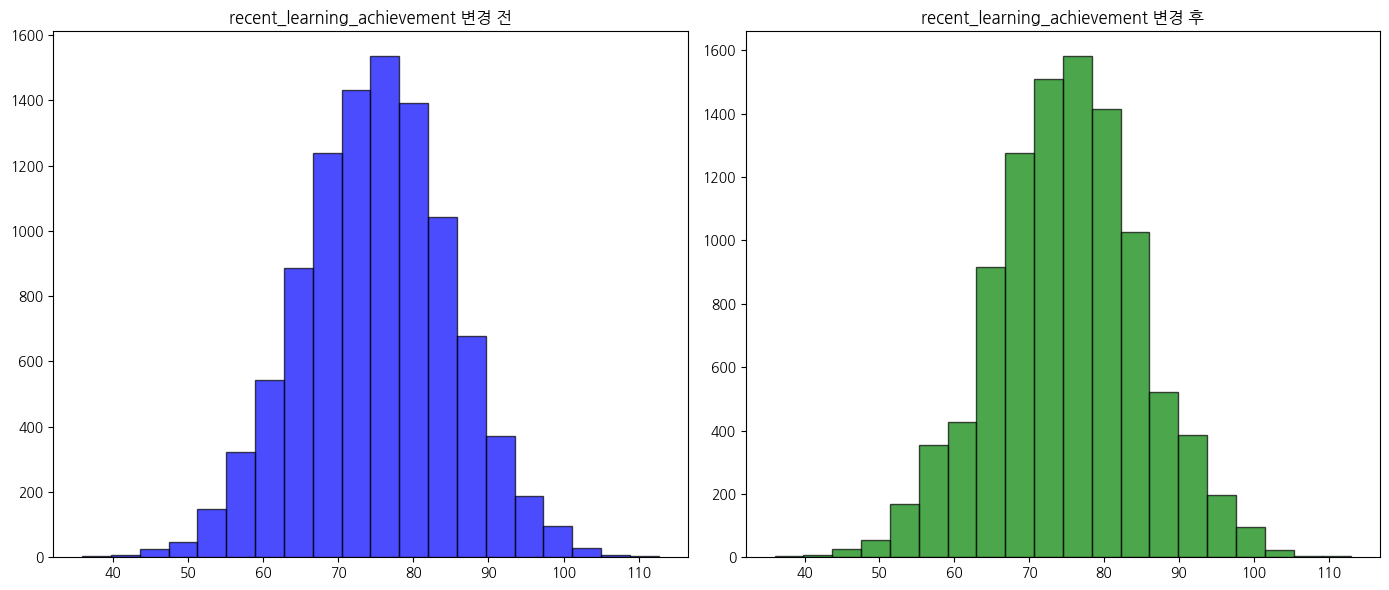

In [23]:
# 원래 데이터와 정수형 데이터의 히스토그램 그리기
plt.figure(figsize=(14, 6))

# 원래 데이터 히스토그램
plt.subplot(1, 2, 1)
plt.hist(data['recent_learning_achievement'], bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('recent_learning_achievement 변경 전')

# 정수형 데이터 히스토그램
# 새로운 열로 정수형 데이터 저장
data['recent_learning_achievement_int'] = data['recent_learning_achievement'].round().astype(int)
plt.subplot(1, 2, 2)
plt.hist(data['recent_learning_achievement_int'], bins=20, alpha=0.7, color='green', edgecolor='black')
plt.title('recent_learning_achievement 변경 후')

plt.tight_layout()
plt.show()

In [29]:
# recent_learning_achievement가 100점 이상인 사용자 필터링
high_achievement_users = data[data['recent_learning_achievement'] > 100]

# 사용자 수 확인
number_of_users = len(high_achievement_users)

# 평균값 계산
average_time_per_learning_session = high_achievement_users['average_time_per_learning_session'].mean()
average_monthly_active_learning_days = high_achievement_users['monthly_active_learning_days'].mean()
average_community_engagement_level = high_achievement_users['community_engagement_level'].mean()
total_completed_courses = high_achievement_users['total_completed_courses'].mean()
# 결과 출력
print("성취도가 100을 초과하는 유저수 :", number_of_users)
print("average_time_per_learning_session 각 학습 세션에 소요된 평균 시간 : ", average_time_per_learning_session)
print("monthly_active_learning_days 월간 활동적인 학습 일수 : ", average_monthly_active_learning_days)
print("community_engagement_level 커뮤니티 참여도 : ", average_community_engagement_level)
print("total_completed_courses: 완료한 총 코스 수 : ", total_completed_courses)

성취도가 100을 초과하는 유저수 : 41
average_time_per_learning_session 각 학습 세션에 소요된 평균 시간 :  43.170731707317074
monthly_active_learning_days 월간 활동적인 학습 일수 :  12.439024390243903
community_engagement_level 커뮤니티 참여도 :  3.731707317073171
total_completed_courses: 완료한 총 코스 수 :  12.146341463414634


In [5]:
#정수형으로 변환하기 
data['average_login_time'] = data['average_login_time'].astype(int)
data['average_time_per_learning_session'] = data['average_time_per_learning_session'].astype(int)
data['recent_learning_achievement'] = data['recent_learning_achievement'].astype(int)



In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   user_id                            10000 non-null  object
 1   subscription_duration              10000 non-null  int64 
 2   recent_login_time                  10000 non-null  int64 
 3   average_login_time                 10000 non-null  int32 
 4   average_time_per_learning_session  10000 non-null  int32 
 5   monthly_active_learning_days       10000 non-null  int64 
 6   total_completed_courses            10000 non-null  int64 
 7   recent_learning_achievement        10000 non-null  int32 
 8   abandoned_learning_sessions        10000 non-null  int64 
 9   community_engagement_level         10000 non-null  int64 
 10  preferred_difficulty_level         10000 non-null  object
 11  subscription_type                  10000 non-null  object
 12  custo

### 1-3. 이상치 확인

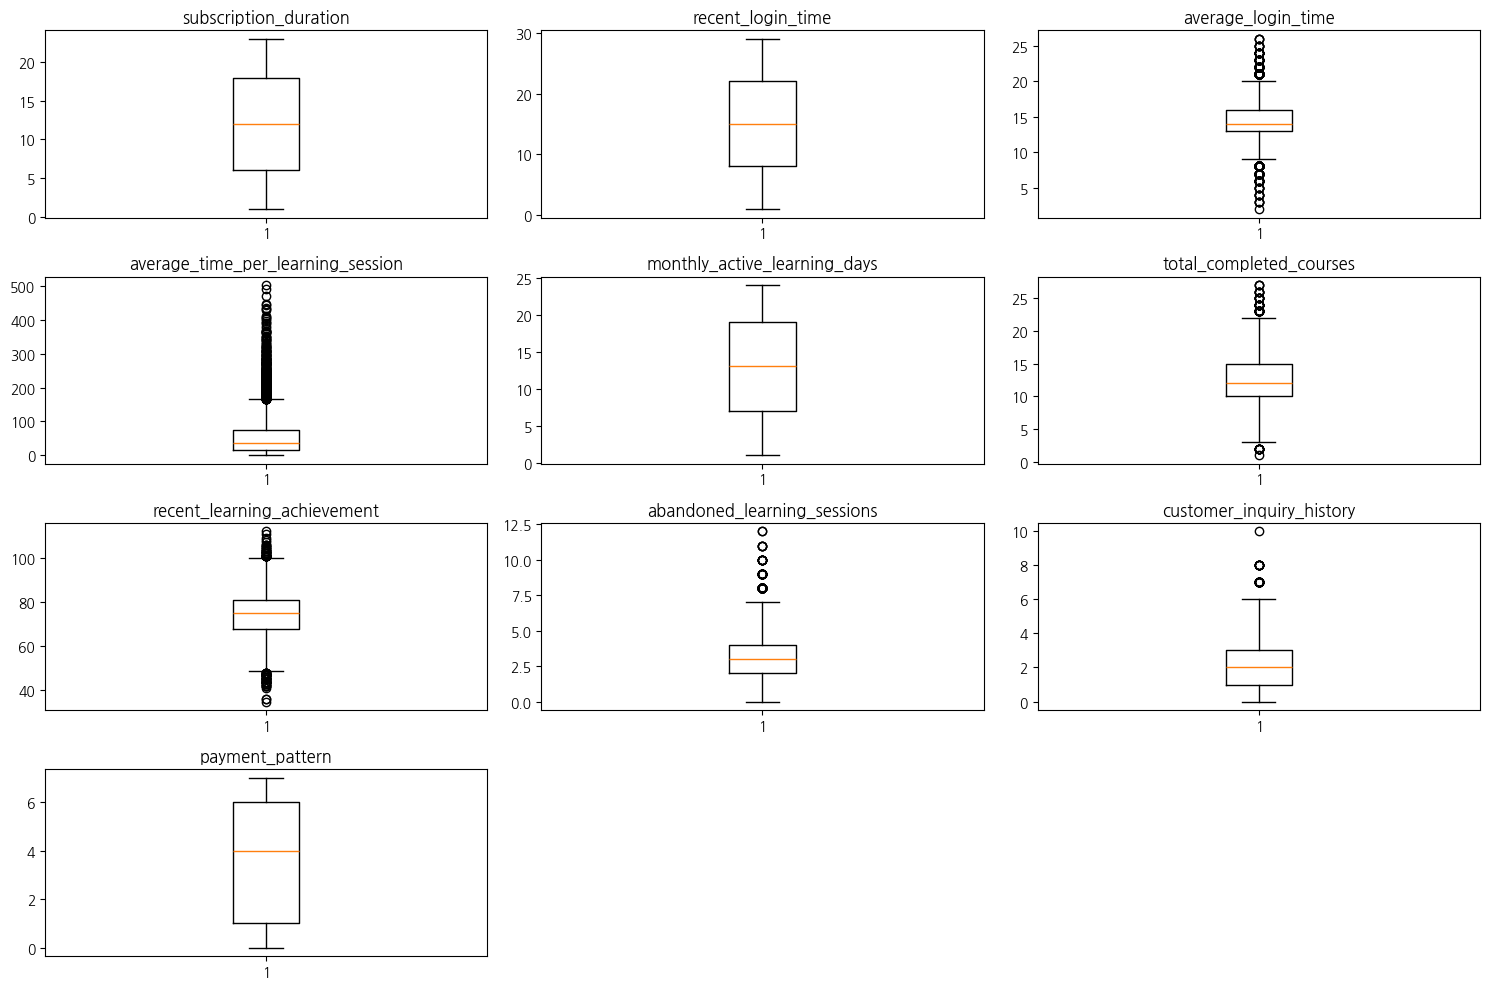

In [33]:
# 숫자형 변수들만 선택하기
numeric_columns = ['subscription_duration', 'recent_login_time', 'average_login_time',
                   'average_time_per_learning_session', 'monthly_active_learning_days', 
                   'total_completed_courses', 'recent_learning_achievement',
                   'abandoned_learning_sessions', 'customer_inquiry_history', 'payment_pattern']

# 각 변수에 대해 박스플롯 그리기
plt.figure(figsize=(15, 10))

for i, column in enumerate(numeric_columns, 1):
    plt.subplot(4, 3, i)  # 4행 3열의 그래프를 만들고 각 그래프의 위치를 지정
    plt.boxplot(data[column])
    plt.title(column)

plt.tight_layout()  # 그래프들이 서로 겹치지 않도록 조정
plt.show()

### 이상치 확인

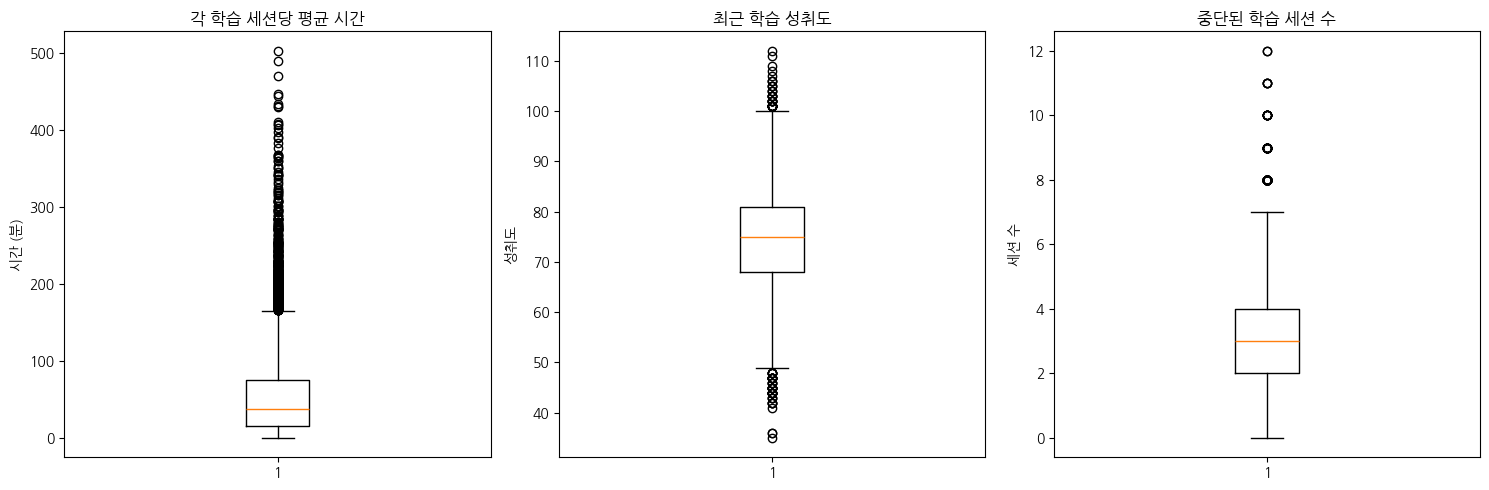

In [7]:
# 1. 각 변수의 기본 통계 확인
stats_average_time = data['average_time_per_learning_session'].describe()
stats_recent_learning = data['recent_learning_achievement'].describe()
stats_abandoned_sessions = data['abandoned_learning_sessions'].describe()

# 2. 박스플롯 시각화
plt.figure(figsize=(15, 5))

# average_time_per_learning_session
plt.subplot(1, 3, 1)
plt.boxplot(data['average_time_per_learning_session'])
plt.title('각 학습 세션당 평균 시간')
plt.ylabel('시간 (분)')

# recent_learning_achievement
plt.subplot(1, 3, 2)
plt.boxplot(data['recent_learning_achievement'])
plt.title('최근 학습 성취도')
plt.ylabel('성취도')

# abandoned_learning_sessions
plt.subplot(1, 3, 3)
plt.boxplot(data['abandoned_learning_sessions'])
plt.title('중단된 학습 세션 수')
plt.ylabel('세션 수')

plt.tight_layout()
plt.show()


### 설명
average_time_per_learning_session (각 학습 세션당 평균 시간):

최대값이 503분으로, 평균값에 비해 상당히 높은 수치입니다.
recent_learning_achievement (최근 학습 성취도):

최소값이 35이고 최대값이 112로, 성취도가 100을 초과하는 값은 특이점으로 보일 수 있습니다.
abandoned_learning_sessions (중단된 학습 세션 수):

최대값이 12로, 이는 다른 값들과 비교했을 때 높은 수치입니다.

In [9]:
# 통계 출력
print("각 학습 세션당 평균 시간 통계:\n", stats_average_time)
print("\n최근 학습 성취도 통계:\n", stats_recent_learning)
print("\n중단된 학습 세션 수 통계:\n", stats_abandoned_sessions)

# 각 통계에 대한 한글 설명
print("\n각 학습 세션당 평균 시간:")
print(f"- 총 데이터 수(count): {stats_average_time['count']}")
print(f"- 평균(mean): {stats_average_time['mean']} 분")
print(f"- 표준편차(std): {stats_average_time['std']} 분")
print(f"- 최소값(min): {stats_average_time['min']} 분")
print(f"- 1사분위수(25%): {stats_average_time['25%']} 분")
print(f"- 중앙값(50%): {stats_average_time['50%']} 분")
print(f"- 3사분위수(75%): {stats_average_time['75%']} 분")
print(f"- 최대값(max): {stats_average_time['max']} 분")

print("\n최근 학습 성취도:")
print(f"- 총 데이터 수(count): {stats_recent_learning['count']}")
print(f"- 평균(mean): {stats_recent_learning['mean']}")
print(f"- 표준편차(std): {stats_recent_learning['std']}")
print(f"- 최소값(min): {stats_recent_learning['min']}")
print(f"- 1사분위수(25%): {stats_recent_learning['25%']}")
print(f"- 중앙값(50%): {stats_recent_learning['50%']}")
print(f"- 3사분위수(75%): {stats_recent_learning['75%']}")
print(f"- 최대값(max): {stats_recent_learning['max']}")

print("\n중단된 학습 세션 수:")
print(f"- 총 데이터 수(count): {stats_abandoned_sessions['count']}")
print(f"- 평균(mean): {stats_abandoned_sessions['mean']}")
print(f"- 표준편차(std): {stats_abandoned_sessions['std']}")
print(f"- 최소값(min): {stats_abandoned_sessions['min']}")
print(f"- 1사분위수(25%): {stats_abandoned_sessions['25%']}")
print(f"- 중앙값(50%): {stats_abandoned_sessions['50%']}")
print(f"- 3사분위수(75%): {stats_abandoned_sessions['75%']}")
print(f"- 최대값(max): {stats_abandoned_sessions['max']}")

각 학습 세션당 평균 시간 통계:
 count    10000.000000
mean        54.423600
std         56.020969
min          0.000000
25%         15.000000
50%         37.000000
75%         75.000000
max        503.000000
Name: average_time_per_learning_session, dtype: float64

최근 학습 성취도 통계:
 count    10000.000000
mean        74.531200
std          9.971999
min         35.000000
25%         68.000000
50%         75.000000
75%         81.000000
max        112.000000
Name: recent_learning_achievement, dtype: float64

중단된 학습 세션 수 통계:
 count    10000.000000
mean         3.043600
std          1.755052
min          0.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         12.000000
Name: abandoned_learning_sessions, dtype: float64

각 학습 세션당 평균 시간:
- 총 데이터 수(count): 10000.0
- 평균(mean): 54.4236 분
- 표준편차(std): 56.020969269906416 분
- 최소값(min): 0.0 분
- 1사분위수(25%): 15.0 분
- 중앙값(50%): 37.0 분
- 3사분위수(75%): 75.0 분
- 최대값(max): 503.0 분

최근 학습 성취도:
- 총 데이터 수(count): 10000.0
- 평균(mean): 74.5312
- 표준편차

### 이상치처리

In [11]:
# 1. 처리 전 데이터 통계 확인
print("처리 전 데이터 통계:")
print("최근 학습 성취도:")
print(data['recent_learning_achievement'].describe())


# 2. recent_learning_achievement에서 이상치 처리
# 평균값을 구하기
mean_achievement = data['recent_learning_achievement'].mean()
# 성취도가 100을 초과하는 경우 평균값으로 대체
data['recent_learning_achievement'] = data['recent_learning_achievement'].where(
    data['recent_learning_achievement'] <= 100, mean_achievement
)


# 4. 처리 후 데이터 통계 확인
print("\n처리 후 데이터 통계:")
print("최근 학습 성취도:")
print(data['recent_learning_achievement'].describe())

처리 전 데이터 통계:
최근 학습 성취도:
count    10000.000000
mean        74.531200
std          9.971999
min         35.000000
25%         68.000000
50%         75.000000
75%         81.000000
max        112.000000
Name: recent_learning_achievement, dtype: float64

처리 후 데이터 통계:
최근 학습 성취도:
count    10000.000000
mean        74.413278
std          9.798054
min         35.000000
25%         68.000000
50%         75.000000
75%         81.000000
max        100.000000
Name: recent_learning_achievement, dtype: float64


구독 연장 사용자 평균 학습 세션 시간: 60 분
구독 취소 사용자 평균 학습 세션 시간: 46 분


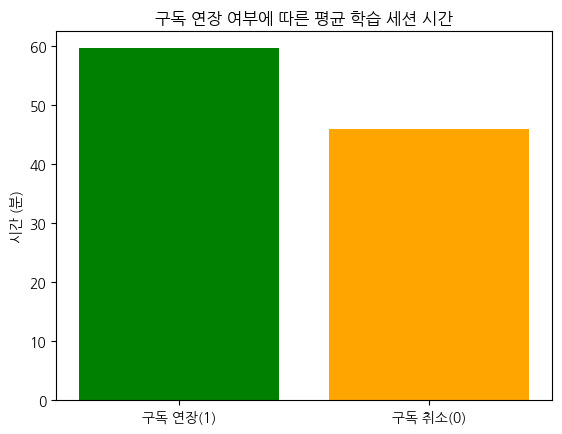

In [13]:
# 구독 연장 여부에 따른 평균 학습 세션 시간 계산
avg_time_renewed = data[data['target'] == 1]['average_time_per_learning_session'].mean()
avg_time_non_renewed = data[data['target'] == 0]['average_time_per_learning_session'].mean()

# 평균 학습 세션 시간 출력
print(f"구독 연장 사용자 평균 학습 세션 시간: {avg_time_renewed:.0f} 분")
print(f"구독 취소 사용자 평균 학습 세션 시간: {avg_time_non_renewed:.0f} 분")

# 시각화
labels = ['구독 연장(1)', '구독 취소(0)']
avg_times = [avg_time_renewed, avg_time_non_renewed]

plt.bar(labels, avg_times, color=['green', 'orange'])
plt.title('구독 연장 여부에 따른 평균 학습 세션 시간')
plt.ylabel('시간 (분)')
plt.show()

- 구독을 연장한 사용자는 평균적으로 60.11분 동안 학습하는 반면, 구독을 취소한 사용자는 평균 46.46분 동안 학습합니다. 
- 이는 구독 연장 사용자가 더 긴 시간 동안 학습 세션을 유지하는 경향이 있음을 보여줍니다.
- 구독 연장 사용자는 평균 60.11분 동안 학습하는 반면, 구독 취소 사용자는 평균 46.46분 동안 학습합니다.
- 시각적으로 보았을 때, 구독 연장 사용자가 더 긴 시간 동안 학습하는 경향이 있음을 확인할 수 있습니다.

### 결론
- 이 결과는 긴 학습 세션 시간이 구독 연장에 긍정적인 영향을 미칠 가능성이 있음을 시사합니다.
- 따라서 **average_time_per_learning_session**에서 발견된 이상치가 사용자 습관에 따른 정상적인 행동일 수 있으며, 이를 무작정 제거하기보다는 그대로 두는 것이 좋을 수 있습니다.

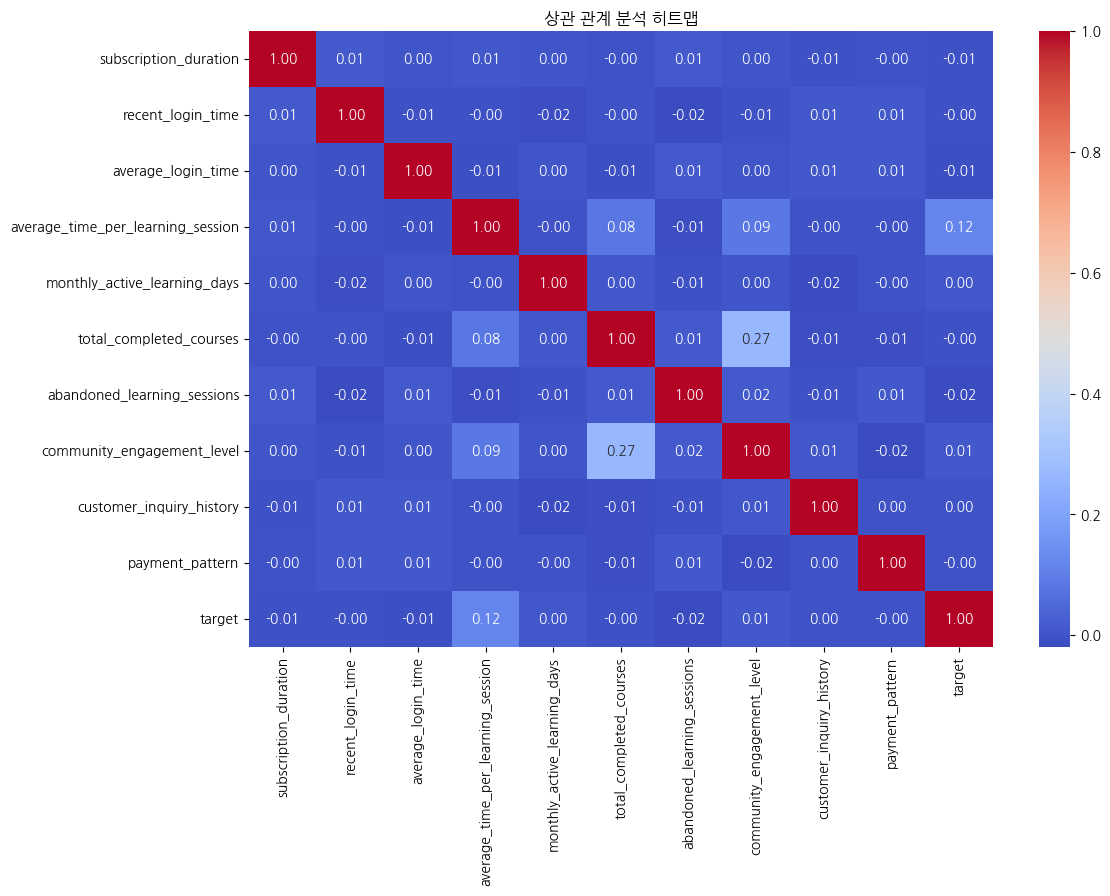

In [19]:
# 숫자형 변수만 선택
numeric_data = data.select_dtypes(include=['int32', 'int64'])

# 상관계수 행렬 계산
correlation_matrix = numeric_data.corr()

# 히트맵 그리기
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('상관 관계 분석 히트맵')
plt.show()

In [23]:
# average_time_per_learning_session이 100보다 많은 사용자 필터링
high_users = data[data['average_time_per_learning_session'] > 100]
# 사용자 수 확인
number_of_high_time_users = len(high_users)

# total_completed_courses와 community_engagement_level의 평균값 계산
average_completed_courses = high_users['total_completed_courses'].mean()
average_engagement = high_users['community_engagement_level'].mean()


# 결과 출력
print("100분보다 많은 유저수 : ", number_of_high_time_users)
print("total_completed_courses 평균:", average_completed_courses)
print("community_engagement_level 평균 :", average_engagement)

100분보다 많은 유저수 :  1563
total_completed_courses 평균: 12.806142034548945
community_engagement_level 평균 : 4.099808061420346


In [146]:
data.describe()

,subscription_duration,recent_login_time,average_login_time,average_time_per_learning_session,monthly_active_learning_days,total_completed_courses,recent_learning_achievement,abandoned_learning_sessions,community_engagement_level,customer_inquiry_history,payment_pattern,target,average_login_time_int
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,11.897400,15.013200,14.495100,54.423600,12.545400,12.227500,74.531200,3.043600,3.886100,2.010500,3.502900,0.619900,14.995200
std,6.600896,8.362573,3.014512,56.020969,6.932239,3.634125,9.971999,1.755052,1.262175,1.420983,2.311261,0.485435,3.018325
min,1.000000,1.000000,2.000000,0.000000,1.000000,1.000000,35.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.000000
25%,6.000000,8.000000,13.000000,15.000000,7.000000,10.000000,68.000000,2.000000,3.000000,1.000000,1.000000,0.000000,13.000000
50%,12.000000,15.000000,14.000000,37.000000,13.000000,12.000000,75.000000,3.000000,4.000000,2.000000,4.000000,1.000000,15.000000
75%,18.000000,22.000000,16.000000,75.000000,19.000000,15.000000,81.000000,4.000000,5.000000,3.000000,6.000000,1.000000,17.000000
max,23.000000,29.000000,26.000000,503.000000,24.000000,27.000000,112.000000,12.000000,5.000000,10.000000,7.000000,1.000000,27.000000


구독 연장 사용자 평균 학습 성취도: 74.43
구독 취소 사용자 평균 학습 성취도: 74.38
성취도가 100을 초과하는 사용자 수: 0명
성취도가 100을 초과하는 사용자 비율: 0.00%


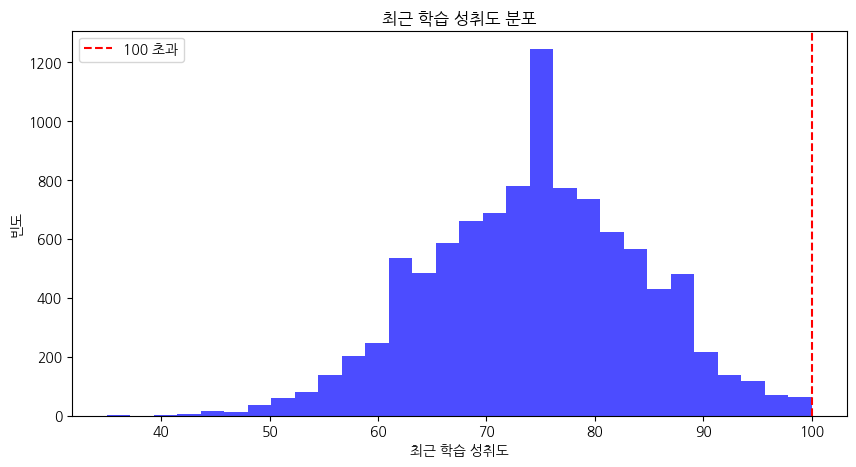

In [41]:
# 구독 연장 여부에 따른 평균 최근 학습 성취도 계산
avg_achievement_renewed = data[data['target'] == 1]['recent_learning_achievement'].mean()
avg_achievement_non_renewed = data[data['target'] == 0]['recent_learning_achievement'].mean()

# 성취도가 100을 초과하는 사용자 수와 비율
above_100_count = len(data[data['recent_learning_achievement'] > 100])
total_count = len(data)
above_100_ratio = above_100_count / total_count

# 성취도 결과 출력
print(f"구독 연장 사용자 평균 학습 성취도: {avg_achievement_renewed:.2f}")
print(f"구독 취소 사용자 평균 학습 성취도: {avg_achievement_non_renewed:.2f}")
print(f"성취도가 100을 초과하는 사용자 수: {above_100_count}명")
print(f"성취도가 100을 초과하는 사용자 비율: {above_100_ratio:.2%}")

# 시각화
plt.figure(figsize=(10, 5))
plt.hist(data['recent_learning_achievement'], bins=30, color='blue', alpha=0.7)
plt.axvline(x=100, color='red', linestyle='--', label='100 초과')
plt.title('최근 학습 성취도 분포')
plt.xlabel('최근 학습 성취도')
plt.ylabel('빈도')
plt.legend()
plt.show()

In [47]:
# recent_learning_achievement가 100점 이상인 사용자 필터링
high_achievement_users = data[data['recent_learning_achievement'] > 100]

# 사용자 수 확인
number_of_users = len(high_achievement_users)

# 평균값 계산
average_time_per_learning_session = high_achievement_users['average_time_per_learning_session'].mean()
average_monthly_active_learning_days = high_achievement_users['monthly_active_learning_days'].mean()
average_community_engagement_level = high_achievement_users['community_engagement_level'].mean()
total_completed_courses = high_achievement_users['total_completed_courses'].mean()
# 결과 출력
print("성취도가 100을 초과하는 유저수 :", number_of_users)
print("average_time_per_learning_session 각 학습 세션에 소요된 평균 시간 : ", average_time_per_learning_session)
print("monthly_active_learning_days 월간 활동적인 학습 일수 : ", average_monthly_active_learning_days)
print("community_engagement_level 커뮤니티 참여도 : ", average_community_engagement_level)
print("total_completed_courses: 완료한 총 코스 수 : ", total_completed_courses)

성취도가 100을 초과하는 유저수 : 0
average_time_per_learning_session 각 학습 세션에 소요된 평균 시간 :  nan
monthly_active_learning_days 월간 활동적인 학습 일수 :  nan
community_engagement_level 커뮤니티 참여도 :  nan
total_completed_courses: 완료한 총 코스 수 :  nan


In [232]:
# 평균 계산
average_time_per_learning_session = data['average_time_per_learning_session'].mean()
average_monthly_active_learning_days = data['monthly_active_learning_days'].mean()
average_community_engagement_level = data['community_engagement_level'].mean()
total_completed_courses = data['total_completed_courses'].mean()

# 결과 출력
print("average_time_per_learning_session 각 학습 세션에 소요된 평균 시간 : ", average_time_per_learning_session)
print("monthly_active_learning_days 월간 활동적인 학습 일수 : ", average_monthly_active_learning_days)
print("community_engagement_level 커뮤니티 참여도 : ", average_community_engagement_level)
print("total_completed_courses: 완료한 총 코스 수 : ", total_completed_courses)

average_time_per_learning_session 각 학습 세션에 소요된 평균 시간 :  54.4236
monthly_active_learning_days 월간 활동적인 학습 일수 :  12.5454
community_engagement_level 커뮤니티 참여도 :  3.8861
total_completed_courses: 완료한 총 코스 수 :  12.2275


abandoned_learning_sessions (중단된 학습 세션 수) 변수를 분석하여 사용자의 행동 패턴과 관련된 통찰력을 얻기 위해 다음과 같은 단계를 진행하겠습니다:

### 분석 계획
- 구독 연장 여부에 따른 중단된 세션 수 비교: 구독을 연장한 사용자와 그렇지 않은 사용자 간의 중단된 학습 세션 수를 비교합니다.
- 중단된 세션 수가 많은 사용자 분석: 중단된 세션 수가 평균 이상인 사용자들의 특징을 분석합니다.
- 시각화: 결과를 시각적으로 확인하여 두 그룹 간의 차이를 파악합니다.

구독 연장 사용자 평균 중단된 세션 수: 3.02
구독 취소 사용자 평균 중단된 세션 수: 3.09
중단된 세션 수가 평균 이상인 사용자 수: 3630명


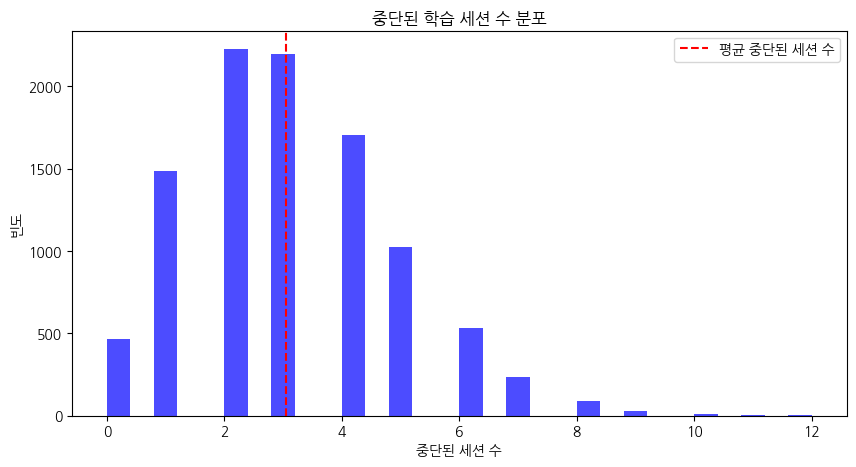

In [124]:
# 구독 연장 여부에 따른 평균 중단된 학습 세션 수 계산
avg_abandoned_renewed = data[data['target'] == 1]['abandoned_learning_sessions'].mean()
avg_abandoned_non_renewed = data[data['target'] == 0]['abandoned_learning_sessions'].mean()

# 중단된 세션 수가 평균 이상인 사용자 수
mean_abandoned_sessions = data['abandoned_learning_sessions'].mean()
high_abandoned_users = data[data['abandoned_learning_sessions'] > mean_abandoned_sessions]
high_abandoned_count = len(high_abandoned_users)

# 결과 출력
print(f"구독 연장 사용자 평균 중단된 세션 수: {avg_abandoned_renewed:.2f}")
print(f"구독 취소 사용자 평균 중단된 세션 수: {avg_abandoned_non_renewed:.2f}")
print(f"중단된 세션 수가 평균 이상인 사용자 수: {high_abandoned_count}명")

# 시각화
plt.figure(figsize=(10, 5))
plt.hist(data['abandoned_learning_sessions'], bins=30, color='blue', alpha=0.7)
plt.axvline(x=mean_abandoned_sessions, color='red', linestyle='--', label='평균 중단된 세션 수')
plt.title('중단된 학습 세션 수 분포')
plt.xlabel('중단된 세션 수')
plt.ylabel('빈도')
plt.legend()
plt.show()

- 이 코드를 실행하면 구독 연장 사용자와 구독 취소 사용자 간의 평균 중단된 학습 세션 수를 비교하고,
- 중단된 세션 수가 평균 이상인 사용자 수를 확인할 수 있습니다. 그리고 중단된 학습 세션 수의 분포를 시각화하여 분석할 수 있습니다

### 구독 연장 여부에 따른 중단된 세션 수:
- 구독 연장 사용자 평균 중단된 세션 수: 약 3.02회
- 구독 취소 사용자 평균 중단된 세션 수: 약 3.09회
- 중단된 세션 수가 평균 이상인 사용자:
- 중단된 세션 수가 평균 이상인 사용자 수: 3,630명
### 결론:
- 구독 연장 사용자와 구독 취소 사용자 간의 평균 중단된 세션 수는 비슷한 수준이며, 큰 차이가 없습니다.
- 중단된 세션 수가 평균 이상인 사용자가 3,630명으로 상당히 많다는 점은 주목할 필요가 있습니다. 이들은 집중력 문제, 기술적 문제 또는 비효율적인 학습 경험 등 다양한 요인으로 인해 세션을 자주 중단하는 것으로 보입니다.

### 분석 결과:
- 빨간 점선은 중단된 세션 수의 평균을 나타내며, 평균값은 약 3.02회입니다.
- 대부분의 사용자가 중단된 세션 수가 0회에서 5회 사이에 분포하고 있으며, 중단 세션 수가 10회 이상인 사용자도 일부 존재합니다.
### 결론:
- 중단된 세션 수가 평균 이상인 사용자가 3,630명으로 많은 수에 해당합니다. 이 사용자들은 중단된 세션 수가 상대적으로 높아, 사용자 집중력이나 기술적 문제로 인한 영향을 받았을 가능성이 있습니다.
- 그래프를 통해 중단된 세션 수가 평균보다 많은 사용자가 대체로 적지 않음을 확인할 수 있습니다.

평균 중단 학습 세션 수: 3.0436
평균 이상인 사용자 수: 3630


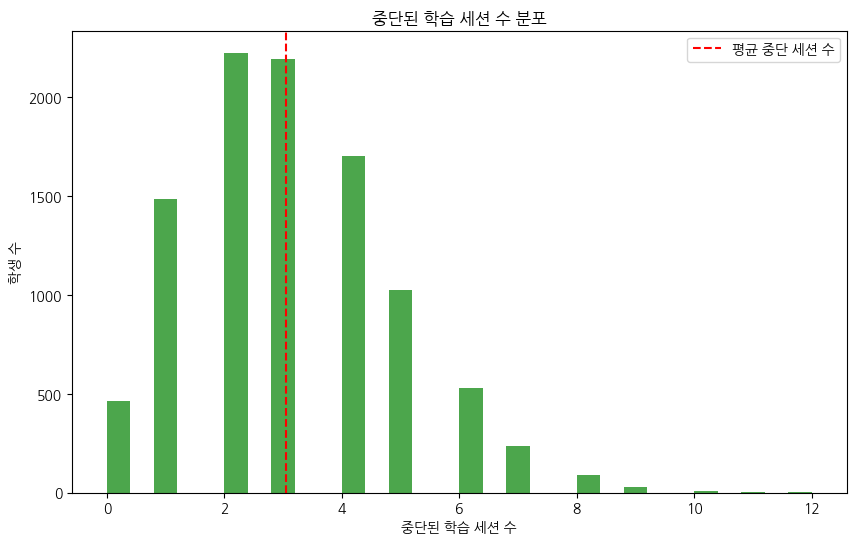

In [242]:
# abandoned_learning_sessions의 평균 계산
average_abandoned_sessions = data['abandoned_learning_sessions'].mean()

# 평균 이상인 사용자 필터링
above_average_abandoned_users = data[data['abandoned_learning_sessions'] > average_abandoned_sessions]

# 해당 사용자 수
number_of_above_average_users = len(above_average_abandoned_users)

# 결과 출력
print("평균 중단 학습 세션 수:", average_abandoned_sessions)
print("평균 이상인 사용자 수:", number_of_above_average_users)

# 시각화
plt.figure(figsize=(10, 6))
plt.hist(data['abandoned_learning_sessions'], bins=30, color='green', alpha=0.7)
plt.axvline(x=average_abandoned_sessions, color='red', linestyle='--', label='평균 중단 세션 수')
plt.title('중단된 학습 세션 수 분포')
plt.xlabel('중단된 학습 세션 수')
plt.ylabel('학생 수')
plt.legend()
plt.show()

### 1. recent_learning_achievement (최근 학습 성취도):
- 이상치 처리 필요성: 성취도가 100을 초과하는 값이 다수 존재하며, 이는 계산 오류나 가산점의 영향을 받을 가능성이 큽니다. 
- 이 변수는 데이터 품질에 직접적인 영향을 미칠 수 있으므로, 이와 관련된 이상치는 처리하는 것이 바람직합니다.
- 성취도 계산 방식이 명확하지 않거나 오류가 있는 경우, 이들을 검토하고 처리할 필요가 있습니다.
  
### 2. abandoned_learning_sessions (중단된 학습 세션 수):
- 이상치 처리 필요성: 중단된 세션 수가 특히 높은 사용자들이 존재하며, 이들은 사용자 집중력 문제나 기술적 결함을 반영할 수 있습니다.
- 이러한 이상치는 사용자의 학습 패턴을 반영하므로, 분석 결과에 영향을 미칠 수 있습니다. 중단된 세션 수가 지나치게 많은 경우, 이를 분석하여 원인을 규명하고 처리하는 것이 좋습니다.
  
### 3. average_time_per_learning_session (각 학습 세션당 평균 시간):
- 이상치 처리 여부: 이 변수는 사용자 습관에 따른 정상적인 행동일 가능성이 있어 무작정 처리하기는 어려울 수 있습니다.
- 그러나 평균이 지나치게 높은 사용자에 대해 추가적인 분석이 필요합니다. 이러한 사용자가 구독 연장에 긍정적인 영향을 미친다면, 이 변수를 그대로 두는 것이 바람직할 수 있습니다.

### 결론:
- **recent_learning_achievement**와 **abandoned_learning_sessions**에서 발견된 이상치는 처리할 필요가 있으며, 특히 성취도 계산 방식의 검토가 중요합니다.
- **average_time_per_learning_session**의 경우, 이상치가 사용자 습관을 반영하고 있을 가능성이 있으므로 추가적인 분석을 통해 판단하는 것이 좋습니다.

In [35]:
# 1. 처리 전 데이터 통계 확인
print("처리 전 데이터 통계:")
print("최근 학습 성취도:")
print(data['recent_learning_achievement'].describe())


# 2. recent_learning_achievement에서 이상치 처리
# 평균값을 구하기
mean_achievement = data['recent_learning_achievement'].mean()
# 성취도가 100을 초과하는 경우 평균값으로 대체
data['recent_learning_achievement'] = data['recent_learning_achievement'].where(
    data['recent_learning_achievement'] <= 100, mean_achievement
)


# 4. 처리 후 데이터 통계 확인
print("\n처리 후 데이터 통계:")
print("최근 학습 성취도:")
print(data['recent_learning_achievement'].describe())


처리 전 데이터 통계:
최근 학습 성취도:
count    10000.000000
mean        74.369981
std          9.740993
min         35.000000
25%         68.000000
50%         74.531200
75%         81.000000
max         99.000000
Name: recent_learning_achievement, dtype: float64

처리 후 데이터 통계:
최근 학습 성취도:
count    10000.000000
mean        74.369981
std          9.740993
min         35.000000
25%         68.000000
50%         74.531200
75%         81.000000
max         99.000000
Name: recent_learning_achievement, dtype: float64


# 상관관계 분석

total_completed_courses 와 community_engagement_level 
average_time_per_learning_session 과 target 이 비교적 높은 상관관계를 보였다.

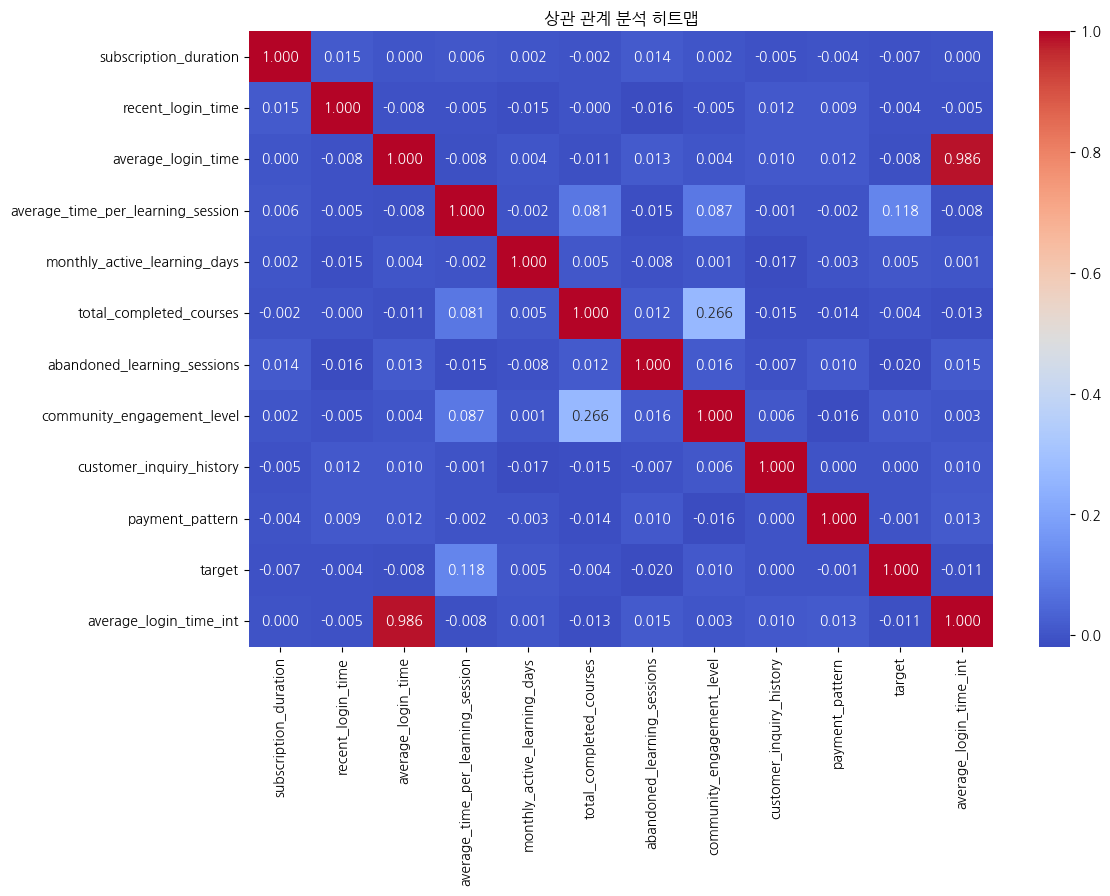

In [262]:
# 숫자형 변수만 선택
numeric_data = data.select_dtypes(include=['int32', 'int64'])

# 상관계수 행렬 계산
correlation_matrix = numeric_data.corr()

# 히트맵 그리기
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f')
plt.title('상관 관계 분석 히트맵')
plt.show()

In [268]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   user_id                            10000 non-null  object 
 1   subscription_duration              10000 non-null  int64  
 2   recent_login_time                  10000 non-null  int64  
 3   average_login_time                 10000 non-null  int32  
 4   average_time_per_learning_session  10000 non-null  int32  
 5   monthly_active_learning_days       10000 non-null  int64  
 6   total_completed_courses            10000 non-null  int64  
 7   recent_learning_achievement        10000 non-null  float64
 8   abandoned_learning_sessions        10000 non-null  int64  
 9   community_engagement_level         10000 non-null  int64  
 10  preferred_difficulty_level         10000 non-null  object 
 11  subscription_type                  10000 non-null  obje

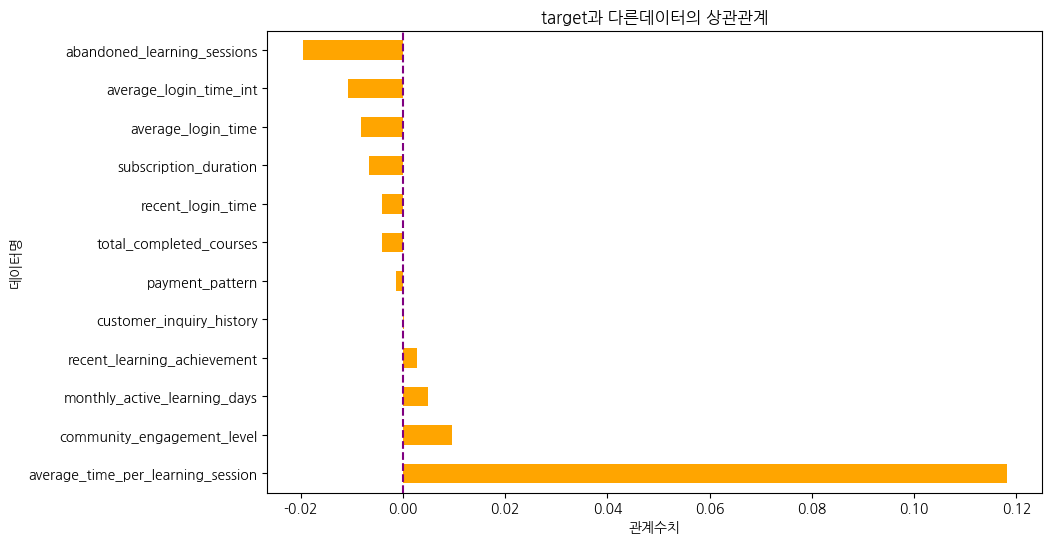

In [288]:
# 숫자형 변수만 선택 (int32, int64, float64 포함)
numeric_data = data.select_dtypes(include=['float64', 'int32', 'int64'])

# 상관계수 행렬 계산
correlation_matrix = numeric_data.corr()

# 타겟 변수와의 상관관계
correlation_with_target = correlation_matrix['target'].sort_values(ascending=False)

# 수평 막대 그래프 생성
plt.figure(figsize=(10, 6))
correlation_with_target = correlation_with_target.drop('target')  # target 제외
correlation_with_target.plot(kind='barh', color='orange')
plt.title('target과 다른데이터의 상관관계')
plt.xlabel('관계수치')
plt.ylabel('데이터명')
plt.axvline(0, color='purple', linestyle='--')  # 기준선 추가
plt.show()

가설 1. 각 학습세션에 소요된 평균시간이 길수록 구독연장을 할까?

상관계수: 0.11820126619438111


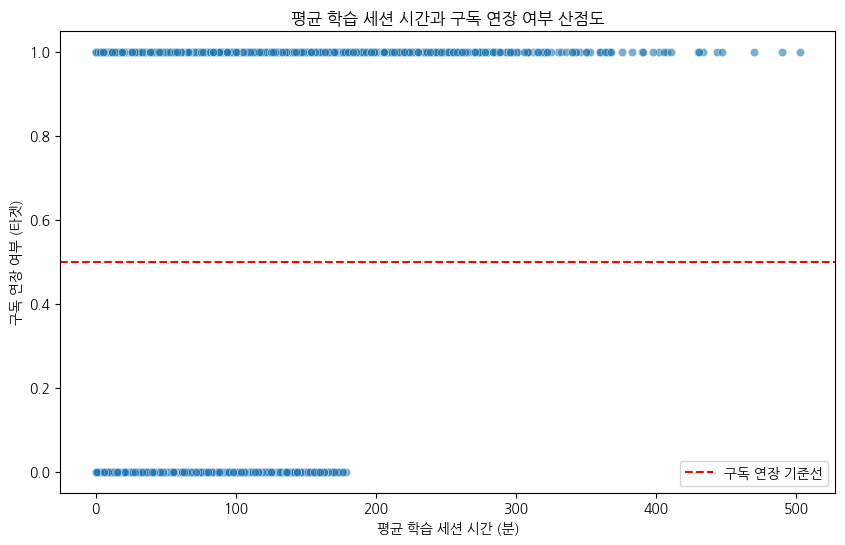

In [301]:
# 사용할 변수 선택
data_subset = data[['average_time_per_learning_session', 'target']]

# 상관계수 계산
correlation = data_subset.corr().loc['average_time_per_learning_session', 'target']
print(f"상관계수: {correlation}")

# 산점도 그리기
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='average_time_per_learning_session', y='target', alpha=0.6)
plt.title('평균 학습 세션 시간과 구독 연장 여부 산점도')
plt.xlabel('평균 학습 세션 시간 (분)')
plt.ylabel('구독 연장 여부 (타겟)')
plt.axhline(0.5, color='red', linestyle='--', label='구독 연장 기준선')
plt.legend()
plt.show()

In [299]:
# 구독 연장자와 취소자의 평균 학습 시간 비교
renewed_users_average_time = data[data['target'] == 1]['average_time_per_learning_session'].mean()
canceled_users_average_time = data[data['target'] == 0]['average_time_per_learning_session'].mean()

print(f"구독 연장자 평균 학습 세션 시간: {renewed_users_average_time:.2f} 분")
print(f"구독 취소자 평균 학습 세션 시간: {canceled_users_average_time:.2f} 분")

구독 연장자 평균 학습 세션 시간: 59.61 분
구독 취소자 평균 학습 세션 시간: 45.97 분


In [335]:
# 프리미엄 사용자 데이터 선택
premium_users = data[data['subscription_type'] == 'Premium']

# 프리미엄 사용자 구독 연장 비율
premium_renewed_ratio = premium_users['target'].mean()
print(f"프리미엄 사용자 구독 연장 비율: {premium_renewed_ratio:.2f}")

프리미엄 사용자 구독 연장 비율: 0.63


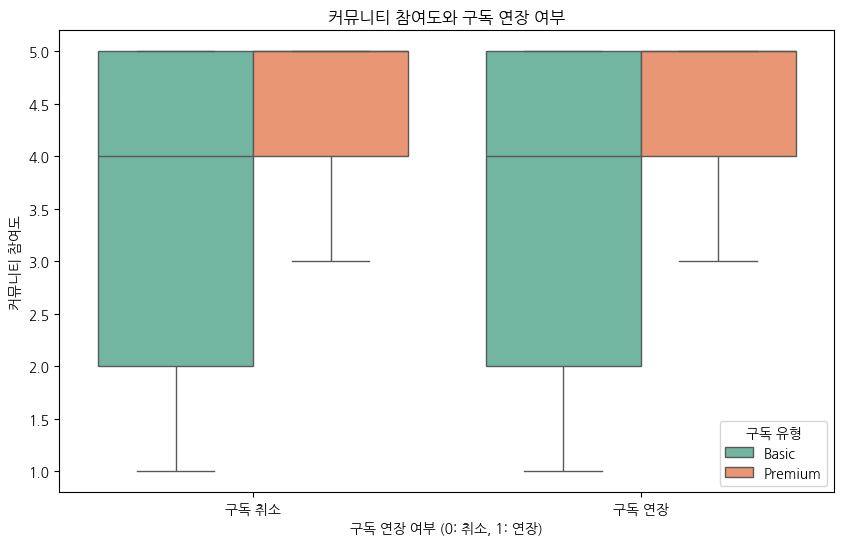

In [339]:

# 박스 플롯 그리기 (hue 인자 추가)
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='community_engagement_level', hue='subscription_type', data=data, palette='Set2', dodge=True)
plt.title('커뮤니티 참여도와 구독 연장 여부')
plt.xlabel('구독 연장 여부 (0: 취소, 1: 연장)')
plt.ylabel('커뮤니티 참여도')
plt.xticks([0, 1], ['구독 취소', '구독 연장'])  # x축 레이블 수정
plt.legend(title='구독 유형')  # 범례 추가
plt.show()

In [51]:
# 월간 활성 학습 일수를 구간으로 나누기
bins = [0, 10, 20, 30]  # 구간 설정: 0-10일, 11-20일, 21일 이상
labels = ['0-10일', '11-20일', '21일 이상']  # 구간 레이블
data['active_learning_days_group'] = pd.cut(data['monthly_active_learning_days'], bins=bins, labels=labels, right=False)

# 각 활성 학습 일수 그룹 내에서 구독 연장(1)과 취소(0)의 수를 세기
grouped_counts = data.groupby(['active_learning_days_group', 'target']).size().unstack(fill_value=0)

# 각 그룹 내에서 구독 연장 비율과 취소 비율 계산
grouped_counts['total'] = grouped_counts.sum(axis=1)
grouped_counts['renewal_ratio'] = grouped_counts[1] / grouped_counts['total'] * 100  # 구독 연장 비율
grouped_counts['cancellation_ratio'] = grouped_counts[0] / grouped_counts['total'] * 100  # 구독 취소 비율

# 결과를 데이터프레임으로 변환
grouped_counts = grouped_counts[['renewal_ratio', 'cancellation_ratio']].reset_index()
grouped_counts.columns = ['활성 학습 일수 그룹', '구독 연장 비율 (%)', '구독 취소 비율 (%)']

# 최종 결과 출력
grouped_counts

C:\Users\jjh52\AppData\Local\Temp\ipykernel_15868\2857013999.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_counts = data.groupby(['active_learning_days_group', 'target']).size().unstack(fill_value=0)


,활성 학습 일수 그룹,구독 연장 비율 (%),구독 취소 비율 (%)
0,0-10일,61.836518,38.163482
1,11-20일,61.255780,38.744220
2,21일 이상,63.683467,36.316533


In [58]:
# total_completed_courses를 기준으로 사용자 그룹을 나누기
bins = [0, 5, 10, float('inf')]  # 구간 설정: 1-5개, 6-10개, 11개 이상
labels = ['1-5개', '6-10개', '11개 이상']  # 구간 레이블
data['total_completed_courses_group'] = pd.cut(data['total_completed_courses'], bins=bins, labels=labels, right=False)

# 각 완료한 강좌 수 그룹 내에서 구독 연장(1)과 취소(0)의 수를 세기
grouped_counts = data.groupby(['total_completed_courses_group', 'target']).size().unstack(fill_value=0)

# 각 그룹 내에서 구독 연장 비율과 취소 비율 계산
grouped_counts['total'] = grouped_counts.sum(axis=1)
grouped_counts['renewal_ratio'] = grouped_counts[1] / grouped_counts['total'] * 100  # 구독 연장 비율
grouped_counts['cancellation_ratio'] = grouped_counts[0] / grouped_counts['total'] * 100  # 구독 취소 비율

# 결과를 데이터프레임으로 변환
grouped_counts = grouped_counts[['renewal_ratio', 'cancellation_ratio']].reset_index()
grouped_counts.columns = ['완료한 강좌 그룹', '구독 연장 비율 (%)', '구독 취소 비율 (%)']

# 최종 결과 출력
grouped_counts

C:\Users\jjh52\AppData\Local\Temp\ipykernel_15868\2082578933.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_counts = data.groupby(['total_completed_courses_group', 'target']).size().unstack(fill_value=0)


,완료한 강좌 그룹,구독 연장 비율 (%),구독 취소 비율 (%)
0,1-5개,70.212766,29.787234
1,6-10개,61.517857,38.482143
2,11개 이상,62.027133,37.972867


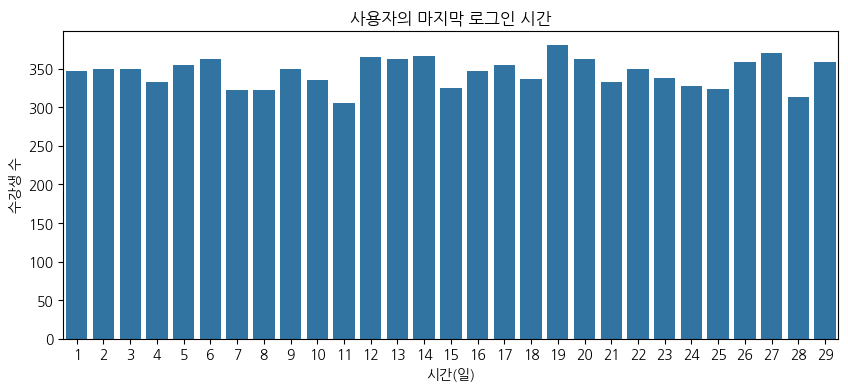

In [80]:
plt.figure(figsize=(10,4))
sns.countplot(x='recent_login_time', data=data)
plt.title('사용자의 마지막 로그인 시간')
plt.xlabel('시간(일)')
plt.ylabel('수강생 수')
plt.show()